---
tags: [tutorial]
---

# はじめての量子カーネル

本チュートリアルでは、Qamomileを初めて使用するユーザーが量子カーネルを定義し、実行するまでの基本的なワークフローを紹介します。一方で、本チュートリアルでは量子計算の基礎や量子アルゴリズムの詳細には踏み込まないことに注意してください。

## Qamomileとは？

Qamomileは量子プログラミングSDKです。Pythonで量子プログラムを記述し、記述したプログラムはサポートされている量子SDK（Qiskit、QuriParts、その他今後対応予定）で実行できます。**型アノテーション付きのシンボリック**なアプローチを採用しており、`@qkernel`デコレータを付けたPython関数を書くと、Qamomileがそれをトレースし、分析・可視化・量子SDKへの変換可能な中間表現が作成できます。

基本的なワークフローは以下のパイプラインです：

```
@qkernel 定義  →  draw() / estimate_resources()  →  transpile()  →  sample() / run()  →  .result()
```

- **定義**：型アノテーション付きの量子カーネル関数を記述
- **検査**：`draw()`で回路図を可視化、`estimate_resources()`で量子ビット数やゲート数を推定
- **トランスパイル**：量子カーネルをユーザーが指定した量子SDKで実行可能形式にトランスパイル
- **実行**：`sample()`（測定ビットの取得）または`run()`（期待値の計算）で実行
- **結果の読み取り**：`.result()`で出力を取得

毎回すべてのステップが必要なわけではありません — タスクに応じて使い分けてください。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

## インストール

通常の使用：

```bash
pip install qamomile
```

このチュートリアルでは、具体的な量子SDKとしてQiskitを使用します。QuriPartsもサポートされており、トランスパイル可能な量子SDKは今後も増えていく予定です。

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## 最初の量子カーネル：偏りのあるコイン

**量子カーネル**とは、`@qmc.qkernel`デコレータを付けたPython関数です。型付きハンドルとゲート操作を使って量子回路を記述します。
> ハンドルとは、あるリソースやオブジェクトを間接的に参照するための「識別子」や「トークン」のことです。

最もシンプルな例を作りましょう：1つの量子ビットを角度`theta`で回転させ、測定します。`theta`の値に応じて、量子ビットは`0`または`1`に偏ります。偏りのあるコイントスのようなイメージです。

In [3]:
@qmc.qkernel
def biased_coin(theta: qmc.Float) -> qmc.Bit:
    # "q" という名前の量子ビットハンドルを作成
    q = qmc.qubit(name="q")

    # RY 回転を適用 — 量子ビットにバイアスをかける
    q = qmc.ry(q, theta)

    # 測定し、結果を古典ビットとして返す
    return qmc.measure(q)

ポイント：

- 型アノテーションは必須です。`theta: qmc.Float`はthetaが浮動小数点パラメータであることを、戻り値の`qmc.Bit`はこの量子カーネルが1つの古典ビットを出力することを示します。
- `qmc.qubit(name="q")`は量子ビットハンドルを作成します。`name`は回路図に表示されます。
- `q = qmc.ry(q, theta)`はRYゲートを適用し、`q`を再代入します。この再代入が重要です — 理由は後述します。
- `qmc.measure(q)`は量子ビットの状態を測定し、`Bit`を返します。

## 実行前の検査

実行前に量子カーネルの確認ができます。`draw()`で回路図を確認しましょう：

> **注意**：`draw()`はQamomileのIRレベルで回路を可視化します。対象の量子SDKへのトランスパイル時にゲートが分解・最適化されることがあるため、実際に実行される回路は`draw()`の表示と異なる場合があります。対象量子SDK固有の回路を確認するには`transpiler.to_circuit()`を使ってください。

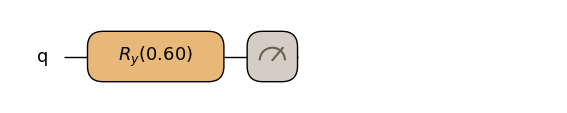

In [4]:
biased_coin.draw(theta=0.6)

コストも事前に確認できます。`estimate_resources()`で量子ビット数やゲート数を推定します：

In [5]:
est = biased_coin.estimate_resources()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)

qubits: 1
total gates: 1


この量子カーネルでは具体的な数値が返りますが、パラメータ付き量子カーネルではSymPyを用いた代数的なリソース推定も可能です —[チュートリアル02](02_parameterized_kernels.ipynb)で詳しく扱います。

## 実行パイプライン

実際に量子カーネルを実行してみましょう。3ステップです：

1. **トランスパイル**：量子カーネルをユーザーが指定した量子SDKで実行可能形式にトランスパイル
2. **実行**：`sample()`で具体的なパラメータ値を与えて実行
3. **結果の読み取り**：Jobの`.result()`で出力を取得

各パートを順に見ていきます：

In [6]:
# ステップ1:トランスパイル
# parameters=["theta"]はトランスパイラに「thetaは後で指定するので、
# トランスパイル済み回路では調整可能なパラメータとして保持せよ」と伝えます。
exe = transpiler.transpile(biased_coin, parameters=["theta"])

# ステップ2:実行
# bindings={"theta": ...}はthetaの具体的な値を指定します。
# shots=256は回路を256回実行することを意味します。
# デフォルトのexecutor（transpiler.executor()）はローカルシミュレータを使用しますが、
# 独自のカスタムexecutor（例:実機やクラウドサービス）を接続することもできます。
job = exe.sample(
    transpiler.executor(),
    shots=256,
    bindings={"theta": math.pi / 4},
)

# ステップ3:結果の読み取り
# .result()はジョブが完了するまで待ち、SampleResultを返します。
result = job.result()

print("sample results:", result.results)

sample results: [(1, 36), (0, 220)]


3つの概念を押さえておきましょう：

- `parameters=["theta"]`（トランスパイル時）— 量子カーネル入力のうち、トランスパイル後もスイープ可能なパラメータとして残すものを宣言します。ここに列挙されていない入力は、実行時に`bindings`で値を与える必要があります（チュートリアル02で詳しく扱います）。

- `bindings={"theta": math.pi / 4}`（実行時）— パラメータに具体的な値を設定します。デフォルトのexecutorはローカルシミュレータですが、カスタムexecutor（実機やクラウドサービス）を使うこともできます。

- `.result()` — `sample()`は結果を直接返すのではなくJobを返します。`.result()`でジョブの完了を待ち、`SampleResult`を取得します。

## `SampleResult`

`result.results`は`list[tuple[T, int]]`で、以下の構造です：

- `T`は測定出力の型（ここでは`int` — `Bit`の場合`0`または`1`）
- `int`はカウント：その結果が何回出現したか

例えば、`[(0, 150), (1, 106)]`は、256ショットのうち結果`0`が150回、結果`1`が106回出現したことを意味します。

In [7]:
for value, count in result.results:
    print(f"  outcome={value}, count={count}")

  outcome=1, count=36
  outcome=0, count=220


`SampleResult`には便利なメソッドも用意されています：

In [8]:
# 最も多い結果
print("most common:", result.most_common(1))

# 確率分布
print("probabilities:", result.probabilities())

most common: [(0, 220)]
probabilities: [(1, 0.140625), (0, 0.859375)]


## トランスパイル後の回路の確認

`to_circuit()`はすべてのパラメータをバインドした状態でトランスパイルし、量子SDK固有の回路（例: Qiskitの`QuantumCircuit`）を返します。量子SDKの形式で回路を確認できるので、デバッグに便利です。

In [9]:
qiskit_circuit = transpiler.to_circuit(
    biased_coin,
    bindings={"theta": math.pi / 4},
)
print(qiskit_circuit)

     ┌─────────┐┌─┐
  q: ┤ Ry(π/4) ├┤M├
     └─────────┘└╥┘
c: 1/════════════╩═
                 0 


## 複数量子ビットの例

量子ビットを複数使ってみましょう。ここでは2つの新しい要素が登場します：

- `qubit_array(n)` — 複数の量子ビットをまとめて確保
- `cx()`（CNOTゲート）— 2量子ビットゲートで、両方のハンドルを返す

In [10]:
@qmc.qkernel
def two_qubit_demo() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, name="q")

    q[0] = qmc.h(q[0])  # q[0] に H ゲートを適用
    q[0], q[1] = qmc.cx(q[0], q[1])  # q[0], q[1] に CNOT を適用

    return qmc.measure(q)

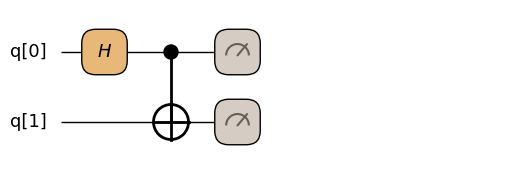

In [11]:
two_qubit_demo.draw()

In [12]:
demo_result = (
    transpiler.transpile(two_qubit_demo)
    .sample(
        transpiler.executor(),
        shots=256,
    )
    .result()
)

for outcome, count in demo_result.results:
    print(f"  outcome={outcome}, count={count}")

  outcome=(0, 0), count=121
  outcome=(1, 1), count=135


2つのパターンに注目してください：

- `qubit_array(2)`で複数の量子ビットをまとめて作成し、`q[0]`、`q[1]`のようにインデックスでアクセスします。チュートリアル02では`qubit_array(n)`でサイズをシンボリックにする方法を扱います。
- 2量子ビットゲートは両方のハンドルを返す：`q[0], q[1] = qmc.cx(q[0], q[1])`。両辺を再代入する必要があります。

これは次に説明する重要なルールにつながります。

## アフィン型システム

Qamomileの量子ハンドルは**アフィン型**です。ゲートがハンドルを消費したら、以降は返された新しいハンドルを**必ず**使う必要があります。

- 1量子ビットゲート：`q = qmc.h(q)` — 同じ変数に再代入する。
- 2量子ビットゲート：`q0, q1 = qmc.cx(q0, q1)` — 両方の変数に再代入する。

### なぜ線型ではなくアフィンなのか？

量子コンピューティングでは、一時的な量子ビットをシステムともつれたまま放置すると、他の量子ビットに予期しない影響を与える可能性があります。厳密には**線型型**（すべてのハンドルをちょうど1回使う）が最も安全ですが、Pythonで線型型を強制すると書きづらくなるため、Qamomileでは**アフィン型**を採用しています：ハンドルは**最大1回**使用でき、ドロップ（使わずに捨てること）も許可されます。

> **トレードオフ**：一時的な量子ビットを他の量子ビットともつれさせた後、そのまま放置するとその一時的な量子ビットが結果に影響を与えることがあります。コンパイラはこれを検出できないので、**一時的な量子ビットをもつれさせたら使い終わる前にアンコンピュートしてください。**

再代入を忘れるとエラーになります。以下はその例です：

In [13]:
try:

    @qmc.qkernel
    def bad_rebind() -> qmc.Bit:
        q = qmc.qubit(name="q")
        qmc.h(q)  # 間違い：q を消費したのに結果をキャプチャしていない
        q = qmc.x(q)  # 古い（既に消費された）ハンドルを使っている
        return qmc.measure(q)

    bad_rebind.draw()
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")

Error type: QubitConsumedError
Error message: Qubit 'qubit_bf3aca38' was already consumed by 'H' and cannot be used again in 'X'.

Affine type rule: Each qubit handle can only be used once. After a gate operation, reassign the result to use the new handle.

Fix:
  q = qm.h(q)  # Reassign to capture the new handle
  q = qm.x(q)  # Use the reassigned handle


修正は簡単です：`qmc.h(q)`ではなく、常に`q = qmc.h(q)`と書いてください。

## まとめ

ここまでで以下ができるようになりました：

- `@qmc.qkernel`で量子カーネルを定義
- 量子ビットの作成、ゲートの適用、測定
- `draw()`で可視化、`estimate_resources()`でコスト見積もり
- `transpile()` → `sample()` → `.result()`で実行
- `SampleResult`から結果を読み取る
- `to_circuit()`でトランスパイル後の回路を確認
- アフィン型（`q = qmc.gate(q)`）に従う

## サポートされている量子SDK

Qamomileは同じ`@qkernel`を異なる量子SDKにトランスパイルします。現在のサポート状況：

| 量子SDK | ステータス | 備考 |
|---------|--------|-------|
| **Qiskit** | サポート済み | 全ゲートセット、制御フロー、オブザーバブル |
| **QuriParts** | サポート済み | 全ゲートセット、オブザーバブル |
| **CUDA-Q** | サポート済み | GPUアクセラレーテッドシミュレーション。対応: forループ（展開）、ランタイム`if`/`if-else`/`while`（`cudaq.run()`経由） |

> **注意**：ランタイム測定依存の制御フロー（`if bit:`、`if/else`、`while bit:`）はQiskitとCUDA-Qの両方でサポートされています。`while`ループの条件は**必ず**測定結果（`qmc.measure()`から得られる`Bit`）でなければなりません。古典変数、定数、比較演算はwhile条件としてサポートされていません。CUDA-Qでは、すべての回路が`@cudaq.kernel`デコレータ関数としてコンパイルされます。ランタイム制御フローを含まない静的回路は`cudaq.sample()` / `cudaq.observe()`経由で実行され、ランタイム測定依存の分岐を含む回路は`cudaq.run()`経由で実行されます。`if`文のコンパイル時定数の条件はすべてのバックエンドで静的に解決されます。

### CUDA-Q プラットフォームサポート

CUDA-Qは以下の環境でサポートされています：

| 環境 | ステータス | 備考 |
|---------|--------|-------|
| Linux | サポート済み | ネイティブ対応 |
| macOS ARM64 (Apple silicon) | サポート済み | CPUシミュレーションのみ; Intel macOSは非対応 |
| Windows (WSL2経由) | サポート済み | WSL2 Linux環境内でインストール・実行 |
| ネイティブWindows | 非対応 | WSL2を使用してください |
| macOS x86_64 (Intel) | 非対応 | Apple siliconのみ対応 |

## 次の章

1. [パラメータ付き量子カーネル](02_parameterized_kernels.ipynb) — 構造パラメータとランタイムパラメータ、バインド/スイープパターン
2. [リソース推定](03_resource_estimation.ipynb) — シンボリックなコスト分析、ゲート内訳、スケーリング分析
3. [実行モデル](04_execution_models.ipynb) — `sample()`と`run()`、オブザーバブル、ビット順序
4. [古典フローパターン](05_classical_flow_patterns.ipynb) — ループ、スパースデータ、条件分岐
5. [再利用パターン](06_reuse_patterns.ipynb) — ヘルパー量子カーネル、コンポジットゲート、スタブ